In [3]:
from pathlib import Path
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

pd.set_option('display.max_rows', 240)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 320)
pd.set_option("display.max_colwidth", 240)
pd.options.display.float_format = "{:.6f}".format

NOTEBOOK_DIR = Path.cwd()
SOURCE_PATH = NOTEBOOK_DIR / "model_panel_start_1970_01_31.parquet"
TRUNC_DATE = pd.Timestamp("2024-11-30")

if not SOURCE_PATH.exists():
    raise FileNotFoundError(f"Missing required input file: {SOURCE_PATH.name}")

panel_raw = pd.read_parquet(SOURCE_PATH).copy()
panel_raw["date"] = pd.to_datetime(panel_raw["date"])
panel_raw = panel_raw.sort_values("date").reset_index(drop=True)
panel_raw = panel_raw.iloc[:, [0] + list(range(49, panel_raw.shape[1]))]

In [4]:
# Export panel_raw for review
panel_raw.head(0).to_csv("panel_columns.csv", index=False)
panel_raw.tail(48).to_csv("panel_recent_48m.csv", index=False)
panel_raw.describe().to_csv("panel_describe.csv")

# 1. Labeling


=== model all_L1 | eq['eq_sortino_1', 'eq_sortino_2', 'eq_sortino_4', 'eq_sortino_l', 'eq_dd_lvl', 'eq_dd_diff', 'eq_ma_cross']
  [all_L1] 1981-12-31 REFIT #1 lam=2.0 eta=1.0 run~7.5m
  [all_L1] 1983-11-30 REFIT #24 lam=2.0 eta=1.0 run~7.5m
  [all_L1] 1985-11-30 REFIT #48 lam=3.0 eta=1.0 run~6.0m
  [all_L1] 1987-11-30 REFIT #72 lam=2.0 eta=1.0 run~6.0m
  [all_L1] 1989-11-30 REFIT #96 lam=2.0 eta=1.0 run~6.7m
  [all_L1] 1991-11-30 REFIT #120 lam=2.0 eta=1.0 run~6.7m
  [all_L1] 1993-11-30 REFIT #144 lam=2.0 eta=2.0 run~5.5m
  [all_L1] 1995-11-30 REFIT #168 lam=2.0 eta=1.0 run~6.0m
  [all_L1] 1997-11-30 REFIT #192 lam=2.0 eta=2.0 run~6.0m
  [all_L1] 1999-11-30 REFIT #216 lam=2.0 eta=1.0 run~5.5m
  [all_L1] 2001-11-30 REFIT #240 lam=2.0 eta=1.0 run~8.6m
  [all_L1] 2003-11-30 REFIT #264 lam=2.0 eta=1.0 run~10.0m
  [all_L1] 2005-11-30 REFIT #288 lam=2.0 eta=1.0 run~8.6m
  [all_L1] 2007-11-30 REFIT #312 lam=2.0 eta=1.0 run~6.0m
  [all_L1] 2009-11-30 REFIT #336 lam=2.0 eta=1.0 run~6.7m
  [all

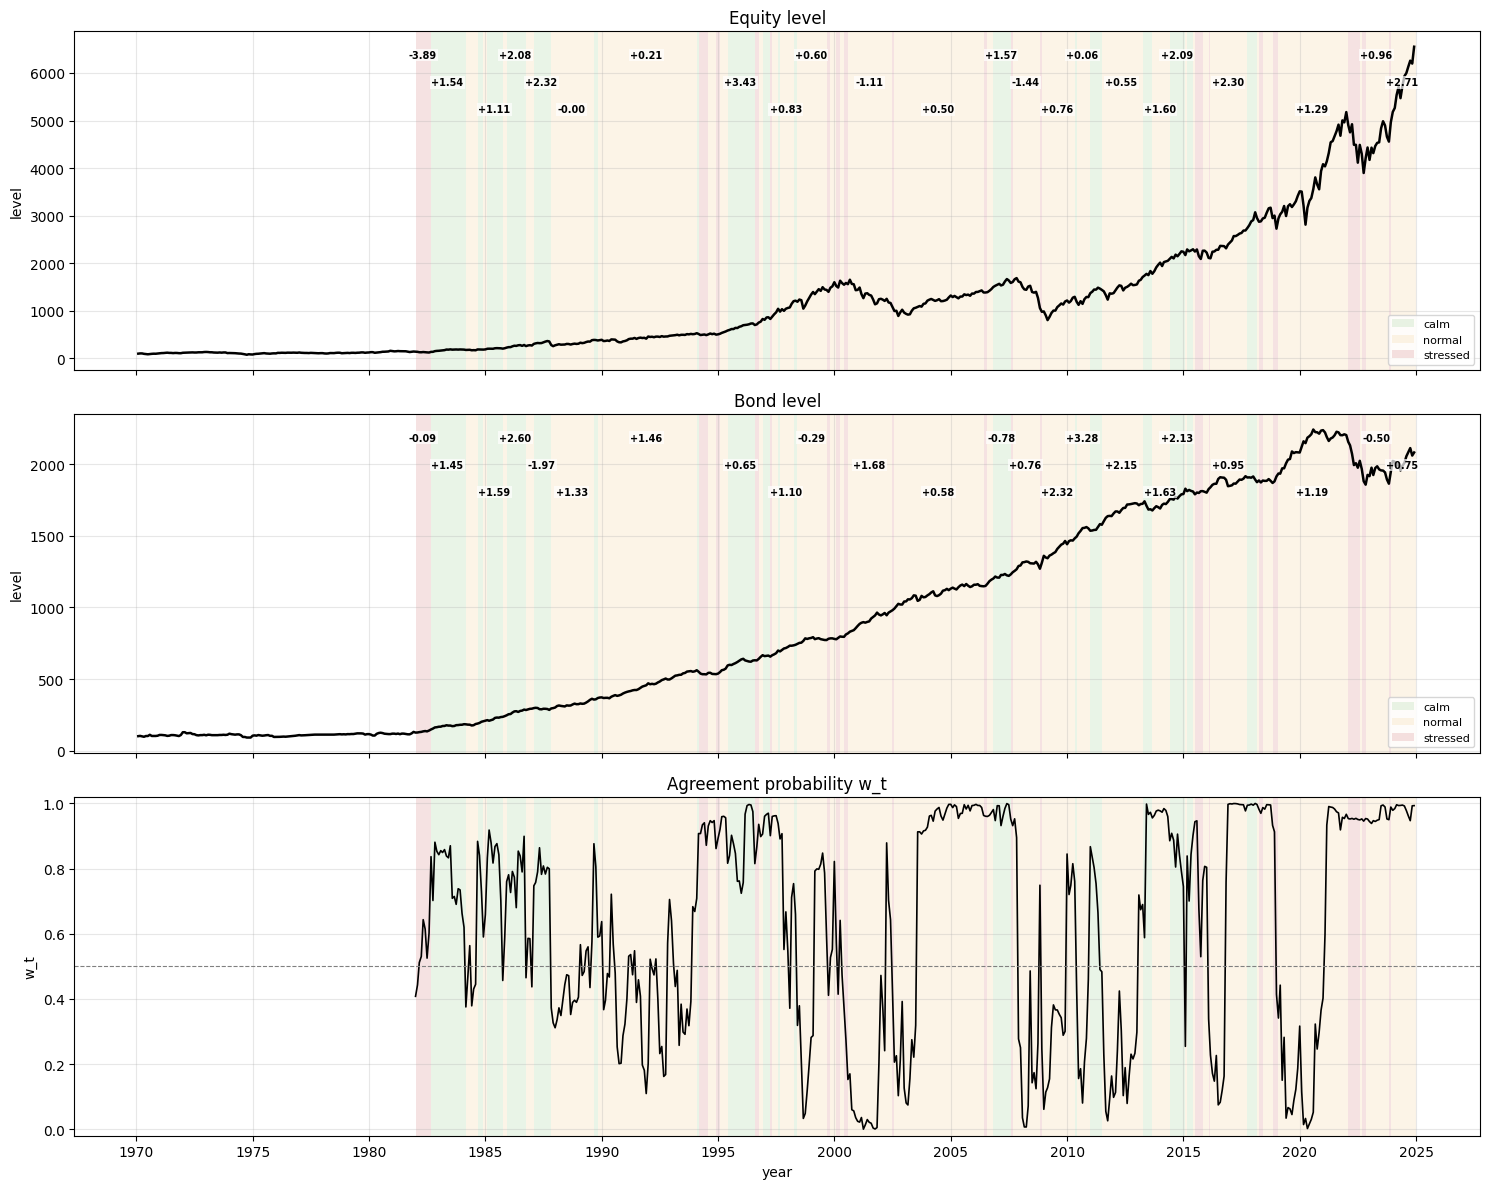

In [ ]:
# =============================================================================
# Teacher models  --  3 STATES (calm/normal/stressed)
# -----------------------------------------------------------------------------
panel = panel_raw.loc[panel_raw["date"] <= TRUNC_DATE].copy()
num_cols = [c for c in panel.columns if c != "date"]
panel[num_cols] = panel[num_cols].apply(pd.to_numeric, errors="coerce").astype("float64")
panel = pd.concat([
    panel,
    pd.DataFrame({"equity_excess": panel["sprtrn_sp500"] - panel["rf"],
                  "bond_excess":   panel["agg_ret"]      - panel["rf"]}, index=panel.index),
], axis=1).copy()
horizon_cutoffs = {"1m": TRUNC_DATE - pd.offsets.MonthEnd(1),
                   "3m": TRUNC_DATE - pd.offsets.MonthEnd(3),
                   "6m": TRUNC_DATE - pd.offsets.MonthEnd(6)}
forward_cols_by_horizon = {"1m": ["sp500_fwd_excess_1m", "bond_fwd_excess_1m"],
                           "3m": ["sp500_fwd_excess_3m", "bond_fwd_excess_3m"],
                           "6m": ["sp500_fwd_excess_6m", "bond_fwd_excess_6m"]}
for h, cols in forward_cols_by_horizon.items():
    keep = [c for c in cols if c in panel.columns]
    if keep:
        panel.loc[panel["date"] > horizon_cutoffs[h], keep] = np.nan
panel = panel.reset_index(drop=True)

# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------
JOINT = np.array([(0, 0), (1, 0), (1, 1)], dtype=np.int8)  # calm/normal/stressed ; (eq_bit, bd_bit): 0=good,1=bad
NS = JOINT.shape[0]
# calm=(0,0) both good ; normal=(1,0) eq uncertain / bd good ; stressed=(1,1) both bad
LABEL_CLASSES = ["calm", "normal", "stressed"]

WARMUP_MONTHS = 132
REFIT_CADENCE = 1
N_INITS_BATCH = 10
MAX_EM_ITERS = 10
EM_TOL = 1e-6
RANDOM_STATE = 42
EPS = 1e-12
STD_WINDOW = 120
WINSOR_P = 0.01
W_CLIP = (0.0, 1.0)

LAMBDA_GRID = [2.0, 3.0, 4.0, 6.0]
ETA_GRID = [1.0, 2.0, 4.0, 8.0]
TARGET_RUN_LO = 18
TARGET_RUN_HI = 48
STRESSED_MAX_SHARE = 0.35
STRESSED_TARGET_SHARE = 0.18
VALIDATION_MONTHS = 60

ENSEMBLE_LAPLACE = 0.5
ENSEMBLE_PROB_HALFLIFE = 3.0
ENSEMBLE_HYSTERESIS = 0.10
TOP_K_MEMBERS = 10
STRESSED_VOTE_THR = 0.33
CALM_VOTE_THR = 0.40
ENSEMBLE_NORMS = ["L1", "L2"]

SELECT_MIN_MONTHS = 60
SELECT_CADENCE    = 6

FEATURE_FAMILIES = {
    "all":           ["sortino_1", "sortino_2", "sortino_4", "sortino_l", "dd_lvl", "dd_diff", "ma_cross"],
    "sortino":       ["sortino_1", "sortino_2", "sortino_4", "sortino_l"],
    "sortino_short": ["sortino_1", "sortino_2", "sortino_4"],
    "dd":            ["dd_lvl", "dd_diff"],
    "trend":         ["ma_cross"],
    "risk":          ["dd_lvl", "sortino_4"],
    "sortino_trend": ["sortino_2", "sortino_4", "ma_cross"],
    "dd_trend":      ["dd_lvl", "ma_cross"],
    "sortino_dd":    ["sortino_2", "sortino_4", "sortino_l", "dd_lvl", "dd_diff"],
    "core":          ["sortino_4", "dd_lvl", "ma_cross"],
    "mom":           ["sortino_2", "ma_cross"],
}

BASE_MACROS = ["rho_eq_bd_12m", "eq_trend", "bd_trend", "eq_dd_lvl", "bd_dd_lvl"]

MACRO_BLOCKS = {
    "corr_trend": ["rho_eq_bd_12m", "eq_trend", "bd_trend"],
    "corr_risk":  ["rho_eq_bd_12m", "eq_dd_lvl", "bd_dd_lvl"],
    "corr_only":  ["rho_eq_bd_12m"],
    "trend_only": ["eq_trend", "bd_trend"],
    "full_mkt":   ["rho_eq_bd_12m", "eq_trend", "bd_trend", "eq_dd_lvl", "bd_dd_lvl"],
}

# =============================================================================
# Risk features
# =============================================================================
def _ewma_trend(x, hl_mean=12, hl_std=24, hl_smooth=6):
    z = x - x.ewm(halflife=hl_mean, adjust=False).mean()
    s = z.ewm(halflife=hl_std, adjust=False).std() + EPS
    g = z / s
    return g.ewm(halflife=hl_smooth, adjust=False).mean()

def build_leg_features(x, pfx):
    dd   = lambda hl: np.sqrt(x.clip(upper=0.0).pow(2).ewm(halflife=hl, adjust=False).mean())
    mean = lambda hl: x.ewm(halflife=hl, adjust=False).mean()
    out = pd.DataFrame(index=x.index)
    for hl, nm in [(1, "sortino_1"), (2, "sortino_2"), (4, "sortino_4"), (12, "sortino_l")]:
        out[f"{pfx}_{nm}"] = mean(hl) / (dd(hl) + EPS)
    out[f"{pfx}_dd_lvl"] = np.log(dd(6) + EPS)
    out[f"{pfx}_dd_diff"] = np.log(dd(2) + EPS) - np.log(dd(12) + EPS)
    out[f"{pfx}_ma_cross"] = (mean(3) - mean(12)) / (dd(6) + EPS)
    out[f"{pfx}_trend"] = _ewma_trend(x)
    return out

EQ_RISK_COLS = ["eq_sortino_1", "eq_sortino_2", "eq_sortino_4", "eq_sortino_l",
                "eq_dd_lvl", "eq_dd_diff", "eq_ma_cross", "eq_trend"]
BD_RISK_COLS = ["bd_sortino_1", "bd_sortino_2", "bd_sortino_4", "bd_sortino_l",
                "bd_dd_lvl", "bd_dd_diff", "bd_ma_cross", "bd_trend"]
JM_EQUITY_COLS = []
JM_BOND_COLS   = []

# =============================================================================
# JM utils
# =============================================================================
def _build_transition_cost(lambda_E, lambda_B):
    L = np.zeros((NS, NS), dtype=float)
    for i, (iE, iB) in enumerate(JOINT):
        for j, (jE, jB) in enumerate(JOINT):
            L[i, j] = lambda_E * (iE != jE) + lambda_B * (iB != jB)
    return L

# agree = equity and bond in the SAME bucket (both good or both bad)
_AGREE = np.array([1.0 if iE == iB else 0.0 for iE, iB in JOINT], dtype=float)
_DISAGREE = 1.0 - _AGREE

def _coupling_for_w(w_scalar, eta):
    return eta * (w_scalar * _DISAGREE + (1.0 - w_scalar) * _AGREE)

def _emission_costs_full(Z_eq, Z_bd, mu_eq, mu_bd, w_arr, eta, norm="L1"):
    if norm == "L2":
        dist = lambda Z, m: np.linalg.norm(Z - m, axis=1)
    else:
        dist = lambda Z, m: np.sum(np.abs(Z - m), axis=1)
    d_eq = np.stack([dist(Z_eq, mu_eq[0]), dist(Z_eq, mu_eq[1])], axis=1)
    d_bd = np.stack([dist(Z_bd, mu_bd[0]), dist(Z_bd, mu_bd[1])], axis=1)
    T = Z_eq.shape[0]; e = np.empty((T, NS))
    for j, (jE, jB) in enumerate(JOINT):
        e[:, j] = d_eq[:, jE] + d_bd[:, jB]
    coupling = eta * (w_arr[:, None] * _DISAGREE[None, :] + (1.0 - w_arr[:, None]) * _AGREE[None, :])
    return e + coupling

def _emission_for_one_obs(z_eq, z_bd, mu_eq, mu_bd, w_scalar, eta, norm="L1"):
    if norm == "L2":
        dd = lambda z, m: float(np.linalg.norm(z - m))
    else:
        dd = lambda z, m: float(np.sum(np.abs(z - m)))
    d_eq = np.array([dd(z_eq, mu_eq[0]), dd(z_eq, mu_eq[1])])
    d_bd = np.array([dd(z_bd, mu_bd[0]), dd(z_bd, mu_bd[1])])
    e = np.empty(NS)
    for j, (jE, jB) in enumerate(JOINT):
        e[j] = d_eq[jE] + d_bd[jB]
    return e + _coupling_for_w(w_scalar, eta)

def _viterbi(e, Lambda):
    T = e.shape[0]; V = np.empty((T, NS)); bp = np.zeros((T, NS), dtype=np.int8)
    V[0] = e[0]
    for t in range(1, T):
        scores = V[t - 1][:, None] + Lambda
        bp[t] = np.argmin(scores, axis=0)
        V[t] = e[t] + scores[bp[t], np.arange(NS)]
    path = np.empty(T, dtype=np.int8); path[-1] = int(np.argmin(V[-1]))
    for t in range(T - 2, -1, -1):
        path[t] = bp[t + 1, path[t + 1]]
    return path, float(V[-1].min())

def _greedy_online_step(z_eq_new, z_bd_new, w_new, A_prev, mu_eq, mu_bd, Lambda, eta, norm="L1"):
    e_new = _emission_for_one_obs(z_eq_new, z_bd_new, mu_eq, mu_bd, w_new, eta, norm)
    A_new = (A_prev[:, None] + Lambda).min(axis=0) + e_new
    return int(np.argmin(A_new)), A_new

CENTER_MODE = "median"

def _center(Z, mask, norm):
    pts = Z[mask] if np.any(mask) else Z
    if norm == "L2":
        return pts.mean(axis=0)
    if CENTER_MODE == "medoid" and len(pts) > 1:
        D = np.abs(pts[:, None, :] - pts[None, :, :]).sum(axis=2).sum(axis=1)
        return pts[int(np.argmin(D))]
    return np.median(pts, axis=0)

def _fit_centroids(Z_eq, Z_bd, s_eq, s_bd, norm="L1"):
    mu_eq = np.stack([_center(Z_eq, s_eq == k, norm) for k in (0, 1)])
    mu_bd = np.stack([_center(Z_bd, s_bd == k, norm) for k in (0, 1)])
    return mu_eq, mu_bd

W_LOGIT_C = 1.0

def _fit_w_logit(X_macro, s_eq, s_bd):
    # Trains w_t = P(legs agree | market). class_weight="balanced" so the
    # majority agree months (calm+stressed) don't bias w_t high and
    # structurally suppress the disagree state (normal)
    y = (s_eq == s_bd).astype(int)
    if y.sum() == 0 or y.sum() == len(y):
        return np.clip(np.full(len(y), float(y.mean())), *W_CLIP), None
    clf = LogisticRegression(penalty="l2", C=W_LOGIT_C, solver="lbfgs", max_iter=400,
                             class_weight="balanced", random_state=RANDOM_STATE)
    clf.fit(X_macro, y)
    return np.clip(clf.predict_proba(X_macro)[:, 1], *W_CLIP), clf

def _fit_batch_jm(Z_eq, Z_bd, X_macro, lambda_E, lambda_B, eta,
                  n_init=N_INITS_BATCH, max_iter=MAX_EM_ITERS, tol=EM_TOL,
                  random_state=RANDOM_STATE, warm_start=None, norm="L1"):
    rng = np.random.default_rng(random_state)
    T = Z_eq.shape[0]; Lambda = _build_transition_cost(lambda_E, lambda_B); best = None
    for init_idx in range(n_init):
        if init_idx == 0 and warm_start is not None:
            ws_eq, ws_bd = warm_start
            if len(ws_eq) >= T:
                s_eq = ws_eq[-T:].copy(); s_bd = ws_bd[-T:].copy()
            else:
                pad = T - len(ws_eq)
                s_eq = np.concatenate([ws_eq, np.repeat(ws_eq[-1], pad)]).astype(np.int8)
                s_bd = np.concatenate([ws_bd, np.repeat(ws_bd[-1], pad)]).astype(np.int8)
        else:
            s_eq = rng.integers(0, 2, size=T).astype(np.int8)
            s_bd = rng.integers(0, 2, size=T).astype(np.int8)
        prev_obj = np.inf; clf = None; w_t = None
        for _ in range(max_iter):
            mu_eq, mu_bd = _fit_centroids(Z_eq, Z_bd, s_eq, s_bd, norm)
            w_t, clf = _fit_w_logit(X_macro, s_eq, s_bd)
            e = _emission_costs_full(Z_eq, Z_bd, mu_eq, mu_bd, w_t, eta, norm)
            path, obj = _viterbi(e, Lambda)
            s_eq, s_bd = JOINT[path, 0].copy(), JOINT[path, 1].copy()
            if abs(prev_obj - obj) < tol: break
            prev_obj = obj
        if best is None or obj < best["obj"]:
            best = {"s_eq": s_eq.copy(), "s_bd": s_bd.copy(),
                    "mu_eq": mu_eq.copy(), "mu_bd": mu_bd.copy(),
                    "w_t": w_t.copy(), "clf": clf, "obj": float(obj),
                    "Lambda": Lambda, "eta": float(eta),
                    "lambda_E": float(lambda_E), "lambda_B": float(lambda_B)}
    return best


# Downside deviation
def _downside_dev(x):
    x = np.asarray(x, float); neg = x[x < 0]
    return float(np.sqrt(np.mean(neg ** 2))) if len(neg) > 0 else 0.0

def _canonicalize_by_risk(fit, eq_ex_win, bd_ex_win):
    s_eq = np.asarray(fit["s_eq"]); s_bd = np.asarray(fit["s_bd"])
    m0 = np.mean(eq_ex_win[s_eq == 0]) if np.any(s_eq == 0) else  np.inf
    m1 = np.mean(eq_ex_win[s_eq == 1]) if np.any(s_eq == 1) else  np.inf
    if m0 < m1:
        fit["s_eq"] = (1 - s_eq).astype(np.int8); fit["mu_eq"] = fit["mu_eq"][[1, 0]].copy()
    mb0 = np.mean(bd_ex_win[s_bd == 0]) if np.any(s_bd == 0) else  np.inf
    mb1 = np.mean(bd_ex_win[s_bd == 1]) if np.any(s_bd == 1) else  np.inf
    if mb0 < mb1:
        fit["s_bd"] = (1 - s_bd).astype(np.int8); fit["mu_bd"] = fit["mu_bd"][[1, 0]].copy()
    return fit

def _joint_idx_to_label(joint_idx):
    iE, iB = JOINT[joint_idx]
    if iE == 0 and iB == 0: return "calm"
    if iE == 1 and iB == 1: return "stressed"
    return "normal"

def _path_to_labels(s_eq, s_bd):
    out = np.empty(len(s_eq), dtype=object)
    for i in range(len(s_eq)):
        e, b = int(s_eq[i]), int(s_bd[i])
        out[i] = "calm" if (e == 0 and b == 0) else ("stressed" if (e == 1 and b == 1) else "normal")
    return out

def _avg_run_length(seq):
    if len(seq) < 2: return float(len(seq))
    ch = sum(1 for i in range(1, len(seq)) if seq[i] != seq[i-1])
    return float(len(seq) / max(ch + 1, 1))

def _sep_score(labs, eq_fwd, bd_fwd, min_n=6):
    labs = np.asarray(labs)
    def _sh(mask):
        r = eq_fwd[mask]; r = r[~np.isnan(r)]
        return (np.sqrt(12) * r.mean() / r.std()) if (len(r) >= min_n and r.std() > 1e-9) else np.nan
    def _shb(mask):
        r = bd_fwd[mask]; r = r[~np.isnan(r)]
        return (np.sqrt(12) * r.mean() / r.std()) if (len(r) >= min_n and r.std() > 1e-9) else np.nan
    eqs = [s for s in (_sh(labs == c) for c in LABEL_CLASSES) if not np.isnan(s)]
    bds = [s for s in (_shb(labs == c) for c in LABEL_CLASSES) if not np.isnan(s)]
    if len(eqs) < 2:
        return -np.inf
    sep = (max(eqs) - min(eqs)) + 0.5 * ((max(bds) - min(bds)) if len(bds) >= 2 else 0.0)
    return float(sep)


# -----------------------------------------------------------------------------
# Rolling standardization: z-score vs last STD_WINDOW months
# -----------------------------------------------------------------------------
def _rolling_z(arr2d, win, winsor_p=WINSOR_P):
    X = np.asarray(arr2d, float); T, K = X.shape; Z = np.empty_like(X)
    for t in range(T):
        lo = max(0, t - win + 1); block = X[lo:t + 1]
        if winsor_p and block.shape[0] >= 10:
            ql = np.nanquantile(block, winsor_p, axis=0)
            qh = np.nanquantile(block, 1.0 - winsor_p, axis=0)
            block = np.clip(block, ql, qh)
            xt = np.clip(X[t], ql, qh)
        else:
            xt = X[t]
        mu = np.nanmean(block, axis=0); sd = np.nanstd(block, axis=0)
        Z[t] = (xt - mu) / np.where(sd > 1e-12, sd, 1.0)
    return Z

def _winsor_bounds(block, winsor_p=WINSOR_P):
    if not winsor_p or block.shape[0] < 10:
        return None, None
    return (np.nanquantile(block, winsor_p, axis=0),
            np.nanquantile(block, 1.0 - winsor_p, axis=0))


# =============================================================================
# Member fit: monthly refit (lambda by run-length target)
# =============================================================================
def _cap_stressed(out_df, eq_trend_series, target=STRESSED_TARGET_SHARE, win=STD_WINDOW):
    df = out_df.merge(eq_trend_series, on="date", how="left").reset_index(drop=True)
    tr = df["eq_ma_cross"].to_numpy(float)
    reg = df["regime"].to_numpy(object).copy()
    for t in range(len(df)):
        if reg[t] != "stressed":
            continue
        lo = max(0, t - win + 1); block = tr[lo:t + 1]; block = block[~np.isnan(block)]
        if len(block) >= 12:
            thr = np.quantile(block, target)
            if not np.isnan(tr[t]) and tr[t] > thr:
                reg[t] = "normal"
    out_df = out_df.copy(); out_df["regime"] = reg
    return out_df

def fit_member(feature_panel, eq_cols, bd_cols, macro_cols, member_name, norm="L1", verbose=True):
    # A feature (e.g. eq_trend, eq_dd_lvl) can be BOTH a member clustering feature
    # and a kappa_t coupling macro. De-duplicate each list and build needed without
    # duplicate labels, otherwise df gets duplicate columns and df[eq_cols] /
    # df[macro_cols] silently double-count that feature in the L1/L2 distance
    _dedup = lambda seq: list(dict.fromkeys(seq))
    eq_cols = _dedup(eq_cols); bd_cols = _dedup(bd_cols); macro_cols = _dedup(macro_cols)
    needed = _dedup(["date", "equity_excess", "bond_excess"] + eq_cols + bd_cols + macro_cols)
    df = feature_panel.loc[feature_panel[needed].notna().all(axis=1), needed].copy() \
                      .sort_values("date").reset_index(drop=True)
    n = len(df); W = WARMUP_MONTHS; V = VALIDATION_MONTHS
    if n < W + 1:
        raise ValueError(f"[{member_name}] insufficient history: {n}")
    date_arr = df["date"].values
    eqX = df[eq_cols].to_numpy(float); bdX = df[bd_cols].to_numpy(float); mcX = df[macro_cols].to_numpy(float)
    eq_ex = df["equity_excess"].to_numpy(float); bd_ex = df["bond_excess"].to_numpy(float)
    out_rows = []; theta = None; A_prev = None; months_since_refit = REFIT_CADENCE
    n_refits = n_online = 0

    for t in range(W, n):
        if months_since_refit >= REFIT_CADENCE - 1:
            Z_eq = _rolling_z(eqX[: t + 1], STD_WINDOW)
            Z_bd = _rolling_z(bdX[: t + 1], STD_WINDOW)
            X_mc = _rolling_z(mcX[: t + 1], STD_WINDOW)
            eqw = eq_ex[: t + 1]; bdw = bd_ex[: t + 1]

            eq_fwd_w = np.concatenate([eqw[1:], [np.nan]])
            bd_fwd_w = np.concatenate([bdw[1:], [np.nan]])
            warm = (theta["s_eq_full"], theta["s_bd_full"]) if theta is not None else None

            best = None; best_key = (-np.inf, np.inf)
            for lam in LAMBDA_GRID:
                for eta_ in ETA_GRID:
                    cand = _fit_batch_jm(Z_eq, Z_bd, X_mc, lam, lam, eta_, n_init=1, warm_start=warm, norm=norm)
                    cand = _canonicalize_by_risk(cand, eqw, bdw)
                    labs = _path_to_labels(cand["s_eq"], cand["s_bd"])
                    labs_arr = np.asarray(labs)

                    sep = _sep_score(labs_arr, eqw, bdw)

                    shares = {c: float(np.mean(labs_arr == c)) for c in LABEL_CLASSES}
                    arl = _avg_run_length(labs[-V:] if len(labs) >= V else labs)
                    ok = (all(shares[c] > 0.02 for c in LABEL_CLASSES)
                          and shares["stressed"] <= STRESSED_MAX_SHARE
                          and arl >= 3.0)
                    if not ok:
                        sep -= 100.0

                    key = (sep, -cand["obj"])
                    if key > best_key:
                        best_key = key; best = cand
            if best is None:
                best = _fit_batch_jm(Z_eq, Z_bd, X_mc, 4.0, 4.0, 2.0, n_init=N_INITS_BATCH, warm_start=warm, norm=norm)
                best = _canonicalize_by_risk(best, eqw, bdw)

            theta = {"mu_eq": best["mu_eq"], "mu_bd": best["mu_bd"], "Lambda": best["Lambda"],
                     "eta": best["eta"], "clf": best["clf"],
                     "s_eq_full": best["s_eq"].copy(), "s_bd_full": best["s_bd"].copy(),
                     "lambda_E": best["lambda_E"], "lambda_B": best["lambda_B"],

                     **(lambda eb, bb, mb: {
                         "eq_lo": _winsor_bounds(eb)[0], "eq_hi": _winsor_bounds(eb)[1],
                         "bd_lo": _winsor_bounds(bb)[0], "bd_hi": _winsor_bounds(bb)[1],
                         "mc_lo": _winsor_bounds(mb)[0], "mc_hi": _winsor_bounds(mb)[1],
                         "eq_mu": np.nanmean(np.clip(eb, *_winsor_bounds(eb)) if _winsor_bounds(eb)[0] is not None else eb, axis=0),
                         "eq_sd": np.nanstd(np.clip(eb, *_winsor_bounds(eb)) if _winsor_bounds(eb)[0] is not None else eb, axis=0),
                         "bd_mu": np.nanmean(np.clip(bb, *_winsor_bounds(bb)) if _winsor_bounds(bb)[0] is not None else bb, axis=0),
                         "bd_sd": np.nanstd(np.clip(bb, *_winsor_bounds(bb)) if _winsor_bounds(bb)[0] is not None else bb, axis=0),
                         "mc_mu": np.nanmean(np.clip(mb, *_winsor_bounds(mb)) if _winsor_bounds(mb)[0] is not None else mb, axis=0),
                         "mc_sd": np.nanstd(np.clip(mb, *_winsor_bounds(mb)) if _winsor_bounds(mb)[0] is not None else mb, axis=0),
                     })(eqX[max(0, t-STD_WINDOW+1):t+1], bdX[max(0, t-STD_WINDOW+1):t+1], mcX[max(0, t-STD_WINDOW+1):t+1])}
            e_full = _emission_costs_full(Z_eq, Z_bd, theta["mu_eq"], theta["mu_bd"], best["w_t"], theta["eta"], norm)
            Tf = e_full.shape[0]; Va = np.empty((Tf, NS)); Va[0] = e_full[0]
            for ti in range(1, Tf):
                Va[ti] = e_full[ti] + (Va[ti - 1][:, None] + theta["Lambda"]).min(axis=0)
            A_prev = Va[-1].copy(); n_refits += 1
            live_label = _joint_idx_to_label(int(np.argmin(A_prev)))
            w_for_log = float(best["w_t"][-1]); months_since_refit = 0
            if verbose and (n_refits == 1 or n_refits % 24 == 0):
                print(f"  [{member_name}] {pd.Timestamp(date_arr[t]).date()} REFIT #{n_refits} "
                      f"lam={theta['lambda_E']} eta={theta['eta']} run~{_avg_run_length(_path_to_labels(best['s_eq'],best['s_bd'])[-V:]):.1f}m")
        else:
            def _z(v, mu, sd, lo=None, hi=None):
                if lo is not None: v = np.clip(v, lo, hi)
                return (v - mu) / np.where(sd > 1e-12, sd, 1.0)
            z_eq_new = _z(eqX[t], theta["eq_mu"], theta["eq_sd"], theta["eq_lo"], theta["eq_hi"])
            z_bd_new = _z(bdX[t], theta["bd_mu"], theta["bd_sd"], theta["bd_lo"], theta["bd_hi"])
            x_mc_new = _z(mcX[t], theta["mc_mu"], theta["mc_sd"], theta["mc_lo"], theta["mc_hi"])
            if theta["clf"] is not None:
                w_for_log = float(np.clip(theta["clf"].predict_proba(x_mc_new.reshape(1, -1))[0, 1], *W_CLIP))
            else:
                w_for_log = 0.5
            ji, A_prev = _greedy_online_step(z_eq_new, z_bd_new, w_for_log, A_prev,
                                             theta["mu_eq"], theta["mu_bd"], theta["Lambda"], theta["eta"], norm)
            live_label = _joint_idx_to_label(ji); months_since_refit += 1; n_online += 1
        out_rows.append({"date": date_arr[t], "regime": live_label, "w_t": w_for_log,
                         "lambda_E": theta["lambda_E"], "eta": theta["eta"]})
    if verbose:
        print(f"  [{member_name}] DONE: {n_refits} refits, {n_online} online")
    res = pd.DataFrame(out_rows)
    if "eq_ma_cross" in feature_panel.columns:
        res = _cap_stressed(res, feature_panel[["date", "eq_ma_cross"]])
    return res


# =============================================================================
# Feature panel + ensemble
# =============================================================================
def build_feature_panel(panel_raw, trunc_date):
    src = panel_raw.loc[panel_raw["date"] <= trunc_date].copy().reset_index(drop=True)
    for col in ["sprtrn_sp500", "agg_ret", "rf"]:
        src[col] = pd.to_numeric(src[col], errors="coerce").astype("float64")
    src["equity_excess"] = src["sprtrn_sp500"] - src["rf"]
    src["bond_excess"] = src["agg_ret"] - src["rf"]
    p = src[["date", "equity_excess", "bond_excess"]].copy()
    eqf = build_leg_features(src["equity_excess"], "eq"); eqf["date"] = src["date"]
    bdf = build_leg_features(src["bond_excess"], "bd"); bdf["date"] = src["date"]
    p = p.merge(eqf, on="date", how="left").merge(bdf, on="date", how="left")
    p["rho_eq_bd_12m"] = src["equity_excess"].rolling(12, min_periods=12).corr(src["bond_excess"])
    return p

def ensemble_configs(panel_columns):
    base = [c for c in BASE_MACROS if c in panel_columns]
    blocks = {"M1_base": [], "M2_slope": ["slope_10y_2y"], "M3_vix": ["vix_logdiff"],
              "M4_rate": ["ratechg_2y"], "M5_rho": ["rho_eq_bd_12m"]}
    configs = []
    for name, extra in blocks.items():
        cols = base + [c for c in extra if c in panel_columns]
        seen = set(); cols2 = [c for c in cols if not (c in seen or seen.add(c))]
        configs.append({"name": name, "macro_cols": cols2})
    return configs

def fit_ensemble(panel_raw, trunc_date, verbose=True):
    feature_panel = build_feature_panel(panel_raw, trunc_date)
    mcols = [c for c in BASE_MACROS if c in feature_panel.columns]

    # fit every member
    member_dfs = {}
    for fam, sfx in FEATURE_FAMILIES.items():
        eq_cols = [f"eq_{s}" for s in sfx if f"eq_{s}" in feature_panel.columns]
        bd_cols = [f"bd_{s}" for s in sfx if f"bd_{s}" in feature_panel.columns]
        if not eq_cols or not bd_cols:
            if verbose: print(f"[skip] family {fam}: empty"); continue
        for norm in ENSEMBLE_NORMS:
            name = f"{fam}_{norm}"
            if verbose: print(f"\n=== model {name} | eq{eq_cols}")
            member_dfs[name] = fit_member(feature_panel, eq_cols, bd_cols,
                                          mcols, name, norm=norm, verbose=verbose)

    member_names = list(member_dfs.keys())

    # align every member on a common monthly axis
    all_dates = sorted(set().union(*[set(df["date"]) for df in member_dfs.values()]))
    didx = {d: i for i, d in enumerate(all_dates)}
    T = len(all_dates)

    counts = {c: np.zeros(T) for c in LABEL_CLASSES}
    n_mem = np.zeros(T); w_acc = np.zeros(T); w_n = np.zeros(T)
    for name, mdf in member_dfs.items():
        for _, row in mdf.iterrows():
            i = didx[row["date"]]
            rg = row["regime"]
            if rg is None or (isinstance(rg, float) and np.isnan(rg)):
                continue
            n_mem[i] += 1
            counts[rg][i] += 1.0
            wv = float(row["w_t"])
            if not np.isnan(wv):
                w_acc[i] += wv; w_n[i] += 1.0

    prob_df = pd.DataFrame({"date": all_dates})
    prob_df["n_members"] = n_mem.astype(int)
    prob_df["w_t"] = np.where(w_n > 0, w_acc / np.maximum(w_n, 1.0), np.nan)
    C = np.vstack([counts[c] for c in LABEL_CLASSES]).T
    valid = n_mem > 0
    tot = C.sum(axis=1, keepdims=True)
    Cf = C / np.maximum(tot, 1e-9)
    for k, c in enumerate(LABEL_CLASSES):
        prob_df[f"p_{c}"] = np.where(valid, Cf[:, k], np.nan)
    path = np.full(T, -1, dtype=int); prev = -1
    for t in range(T):
        if not valid[t]:
            path[t] = prev; continue
        path[t] = int(C[t].argmax()); prev = path[t]
    prob_df["regime"] = [LABEL_CLASSES[i] if i >= 0 else np.nan for i in path]

    if verbose:
        seq = prob_df.loc[prob_df["regime"].notna(), "regime"].to_numpy()
        n_ch = int((seq[1:] != seq[:-1]).sum()) if len(seq) > 1 else 0
        print(f"\n  [ensemble] ALL {len(member_dfs)} members, equal-weight vote (no selection)")
        print(f"  [ensemble] {n_ch} changes, avg run {len(seq)/max(n_ch+1,1):.1f}m")
    selected_labels = prob_df.loc[prob_df["regime"].notna()].copy().reset_index(drop=True)
    return selected_labels, member_dfs, feature_panel


# =============================================================================
# Driver
# =============================================================================
selected_labels, member_label_dfs, feature_panel = fit_ensemble(panel_raw, TRUNC_DATE, verbose=True)

jm_labels = selected_labels.copy()
jm_labels["eq_label"] = np.where(jm_labels["regime"] == "calm", "bull", "bear")
jm_labels["bd_label"] = np.where(jm_labels["regime"] == "stressed", "bear", "bull")

print("\nENSEMBLE_SUMMARY")
print(f"  n monthly labels: {len(selected_labels)}")
print(f"  range: {selected_labels['date'].min().date()} -> {selected_labels['date'].max().date()}")
for c in LABEL_CLASSES:
    print(f"  share {c:>9s}: {(selected_labels['regime'] == c).mean():.3f}")
changes = (selected_labels["regime"].values[1:] != selected_labels["regime"].values[:-1]).sum()
print(f"  changes: {changes} -> avg run {len(selected_labels)/(changes+1):.1f}m, {changes/((selected_labels['date'].max()-selected_labels['date'].min()).days/365.25):.2f}/yr")
for name, mdf in member_label_dfs.items():
    ch = (mdf["regime"].values[1:] != mdf["regime"].values[:-1]).sum()
    print(f"  member {name:<10s}: {ch} changes, avg run {len(mdf)/(ch+1):.1f}m")

_c = panel_raw[["date","sprtrn_sp500","agg_ret","rf"]].copy()
_c = _c[_c["date"] <= TRUNC_DATE].reset_index(drop=True)
_c["eqx"] = _c["sprtrn_sp500"] - _c["rf"]
_c["bdx"] = _c["agg_ret"]      - _c["rf"]
_cm = selected_labels[["date","regime"]].merge(_c[["date","eqx","bdx"]], on="date", how="left").dropna()
print("\nPER_REGIME_CONTEMPORANEOUS (same-month excess, annualised)")
for c in LABEL_CLASSES:
    s = _cm[_cm["regime"] == c]
    if len(s) > 2:
        e_sr = np.sqrt(12)*s["eqx"].mean()/s["eqx"].std()
        b_sr = np.sqrt(12)*s["bdx"].mean()/s["bdx"].std()
        e_ret, e_vol = 12*s["eqx"].mean(), np.sqrt(12)*s["eqx"].std()
        b_ret, b_vol = 12*s["bdx"].mean(), np.sqrt(12)*s["bdx"].std()
        print(f"  {c:>9s} (n={len(s):3d})  eq: SR={e_sr:+.2f} ret={e_ret:+.1%} vol={e_vol:.0%}  |  "
              f"bd: SR={b_sr:+.2f} ret={b_ret:+.1%} vol={b_vol:.0%}")

# -----------------------------------------------------------------------------
# Plots
# -----------------------------------------------------------------------------

plot_df = panel_raw[["date","sprtrn_sp500","agg_ret","rf"]].copy()
plot_df = plot_df.loc[plot_df["date"] <= TRUNC_DATE].reset_index(drop=True)
plot_df["equity_level"] = 100.0*(1.0+plot_df["sprtrn_sp500"]).cumprod()
plot_df["bond_level"] = 100.0*(1.0+plot_df["agg_ret"]).cumprod()
plot_df["equity_excess_now"] = (plot_df["sprtrn_sp500"]-plot_df["rf"])
plot_df["bond_excess_now"] = (plot_df["agg_ret"]-plot_df["rf"])
REGIME_COLORS = {"calm":"#a8d5a2","normal":"#f5d6a0","stressed":"#d98c8c"}
def cspans(ds, rs):
    d=pd.DataFrame({"date":pd.to_datetime(ds),"regime":pd.Series(rs)}).dropna().reset_index(drop=True)
    out=[]; s=p=d.loc[0,"date"]; cur=d.loc[0,"regime"]
    for i in range(1,len(d)):
        dt,rg=d.loc[i,"date"],d.loc[i,"regime"]
        if rg!=cur: out.append((s,p,cur)); s=dt; cur=rg
        p=dt
    out.append((s,p,cur)); return out
def shade(ax,rdf):
    for s,e,rg in cspans(rdf["date"],rdf["regime"]):
        ax.axvspan(s,e+pd.offsets.MonthEnd(1),color=REGIME_COLORS[rg],alpha=0.25,lw=0)
def span_sr(df,a,b,col):
    sub=df.loc[(df["date"]>=a)&(df["date"]<=b),col].dropna().astype(float)
    if len(sub)<3: return np.nan
    v=float(sub.std(ddof=0)); return float(np.sqrt(12)*sub.mean()/v) if v>1e-12 else np.nan
def sr_labels(ax,rdf,rdf2,col,ys=(0.93,0.85,0.77)):
    ylo,yhi=ax.get_ylim(); yp=[ylo+f*(yhi-ylo) for f in ys]; idx=0
    for s,e,rg in cspans(rdf["date"],rdf["regime"]):
        if (e-s).days/30.0<6: continue
        sr=span_sr(rdf2,s,e,col)
        if not np.isfinite(sr): continue
        ax.text(s+(e-s)/2,yp[idx%len(yp)],f"{sr:+.2f}",ha="center",va="center",fontsize=7,
                fontweight="bold",bbox=dict(facecolor="white",edgecolor="none",alpha=0.7,pad=1.0)); idx+=1
fig,axes=plt.subplots(3,1,figsize=(15,12),sharex=True)
axes[0].plot(plot_df["date"],plot_df["equity_level"],lw=1.8,color="black"); shade(axes[0],selected_labels)
axes[0].set_title("Equity level"); axes[0].set_ylabel("level"); axes[0].grid(True,alpha=0.3)
axes[1].plot(plot_df["date"],plot_df["bond_level"],lw=1.8,color="black"); shade(axes[1],selected_labels)
axes[1].set_title("Bond level"); axes[1].set_ylabel("level"); axes[1].grid(True,alpha=0.3)
leg=[Patch(facecolor=REGIME_COLORS[c],alpha=0.25,label=c) for c in LABEL_CLASSES]
axes[0].legend(handles=leg,loc="lower right",fontsize=8); axes[1].legend(handles=leg,loc="lower right",fontsize=8)
sr_labels(axes[0],selected_labels,plot_df,"equity_excess_now"); sr_labels(axes[1],selected_labels,plot_df,"bond_excess_now")
axes[2].plot(selected_labels["date"],selected_labels["w_t"],lw=1.2,color="black")
axes[2].axhline(0.5,color="grey",ls="--",lw=0.8); axes[2].set_ylim(-0.02,1.02)
axes[2].set_title("Agreement probability w_t"); axes[2].set_ylabel("w_t"); axes[2].set_xlabel("year"); axes[2].grid(True,alpha=0.3)
shade(axes[2],selected_labels)
axes[2].xaxis.set_major_locator(mdates.YearLocator(base=5)); axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

In [6]:
import pickle; pickle.dump({k: v for k, v in list(globals().items()) if k in ("selected_labels","member_label_dfs","feature_panel","jm_labels","plot_df","panel","panel_raw","LABEL_CLASSES","REGIME_COLORS","TRUNC_DATE","JOINT","NS","FEATURE_FAMILIES","BASE_MACROS","MACRO_BLOCKS","EQ_RISK_COLS","BD_RISK_COLS")}, open("teacher_run_full.pkl","wb"), protocol=pickle.HIGHEST_PROTOCOL)
print("SAVED -> teacher_run_full.pkl :", [k for k in ("selected_labels","member_label_dfs","feature_panel","jm_labels","plot_df") if k in globals()])

SAVED -> teacher_run_full.pkl : ['selected_labels', 'member_label_dfs', 'feature_panel', 'jm_labels', 'plot_df']
